# Inspect kNN smoothing TSVs

This notebook prints row/column names and compares the value distributions of the input counts TSV and the kNN-smoothed output TSV.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

# Edit these paths if your filenames differ.
input_tsv = Path('knn_smooth_outputs/states_with_plaque_info_type_14mWT_totalRNA_counts.input.tsv')
output_tsv = Path('knn_smooth_outputs/states_with_plaque_info_type_14mWT_totalRNA_counts.knn_k16_d20.tsv')

print('input exists:', input_tsv.exists(), input_tsv)
print('output exists:', output_tsv.exists(), output_tsv)

input exists: True knn_smooth_outputs/states_with_plaque_info_type_14mWT_totalRNA_counts.input.tsv
output exists: True knn_smooth_outputs/states_with_plaque_info_type_14mWT_totalRNA_counts.knn_k16_d20.tsv


In [2]:
def read_names(path, n=10, sep='\t'):
    with Path(path).open('r', encoding='utf-8') as fh:
        header = fh.readline().rstrip('\n').split(sep)
        col_names = header[1:n + 1]
        row_names = []
        for _ in range(n):
            line = fh.readline()
            if not line:
                break
            row_names.append(line.split(sep, 1)[0])
    return row_names, col_names

input_rows, input_cols = read_names(input_tsv, n=10)
output_rows, output_cols = read_names(output_tsv, n=10)

print('Input first row names:')
print(input_rows)
print('\nInput first column names:')
print(input_cols)

print('\nOutput first row names:')
print(output_rows)
print('\nOutput first column names:')
print(output_cols)

print('\nFirst row names identical:', input_rows == output_rows)
print('First column names identical:', input_cols == output_cols)

Input first row names:
['1700019D03Rik', 'A2m', 'Aamp', 'Abat', 'Abca1', 'Abcb1a', 'Abcc9', 'Abcg2', 'Abhd2', 'Abi2']

Input first column names:
['14mWT-3', '14mWT-58', '14mWT-59', '14mWT-86', '14mWT-88', '14mWT-90', '14mWT-97', '14mWT-116', '14mWT-117', '14mWT-118']

Output first row names:
['1700019D03Rik', 'A2m', 'Aamp', 'Abat', 'Abca1', 'Abcb1a', 'Abcc9', 'Abcg2', 'Abhd2', 'Abi2']

Output first column names:
['14mWT-3', '14mWT-58', '14mWT-59', '14mWT-86', '14mWT-88', '14mWT-90', '14mWT-97', '14mWT-116', '14mWT-117', '14mWT-118']

First row names identical: True
First column names identical: True


In [8]:
def sample_values(path, chunksize=200, sample_per_chunk=200_000, seed=0):
    rng = np.random.default_rng(seed)
    samples = []
    total_values = 0
    total_nonzero = 0
    total_sum = 0.0
    total_sumsq = 0.0
    global_min = np.inf
    global_max = -np.inf

    for chunk in pd.read_csv(path, sep='\t', index_col=0, chunksize=chunksize):
        values = chunk.to_numpy(dtype=np.float64, copy=False).ravel()
        values = values[np.isfinite(values)]
        if values.size == 0:
            continue

        total_values += values.size
        total_nonzero += int(np.count_nonzero(values))
        total_sum += float(values.sum())
        total_sumsq += float(np.square(values).sum())
        global_min = min(global_min, float(values.min()))
        global_max = max(global_max, float(values.max()))

        if values.size > sample_per_chunk:
            idx = rng.choice(values.size, size=sample_per_chunk, replace=False)
            samples.append(values[idx])
        else:
            samples.append(values.copy())

    sample = np.concatenate(samples)
    mean = total_sum / total_values
    std = np.sqrt(max(total_sumsq / total_values - mean * mean, 0.0))
    summary = {
        'values': total_values,
        'sample_size': sample.size,
        'nonzero_fraction': total_nonzero / total_values,
        'min': global_min,
        'q25': np.quantile(sample, 0.25),
        'median': np.quantile(sample, 0.50),
        'mean': mean,
        'q75': np.quantile(sample, 0.75),
        'q90': np.quantile(sample, 0.90),
        'q95': np.quantile(sample, 0.95),
        'q99': np.quantile(sample, 0.99),
        'max': global_max,
        'std': std,
    }
    return sample, summary

input_sample, input_summary = sample_values(input_tsv, seed=1)
output_sample, output_summary = sample_values(output_tsv, seed=1)

summary_df = pd.DataFrame([input_summary, output_summary], index=['input', 'output'])
summary_df

,values,sample_size,nonzero_fraction,min,q25,median,mean,q75,q90,q95,q99,max,std
input,74272828,3000000,0.083203,0.0,0.0,0.0,0.117179,0.0,0.0,1.0,2.0,188.0,0.618317
output,74272828,3000000,0.568226,0.0,0.0,1.0,1.974208,2.0,5.0,7.0,19.0,2272.0,7.929807


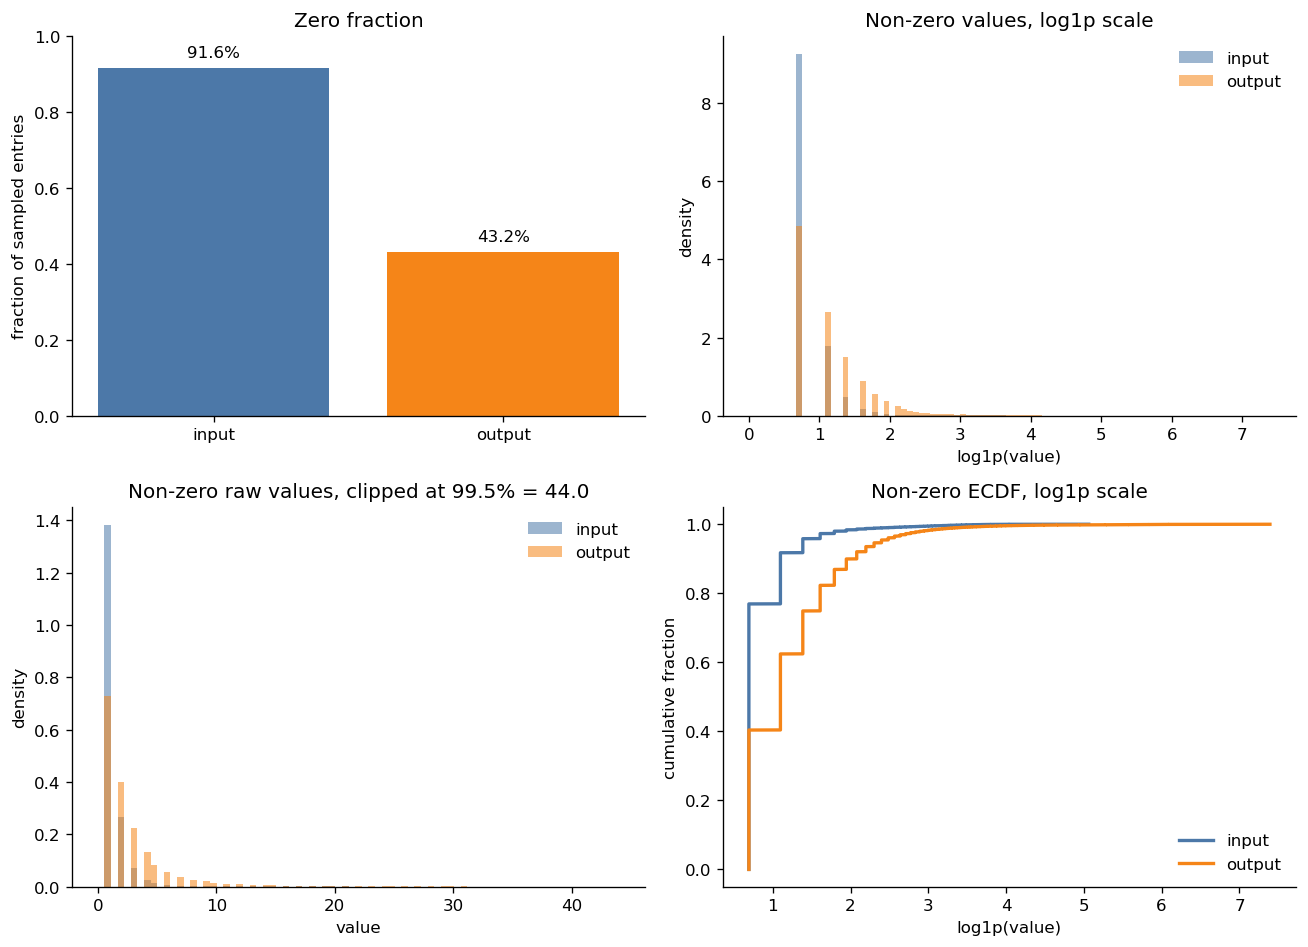

In [9]:
def ecdf(values):
    values = np.sort(values)
    y = np.arange(1, values.size + 1) / values.size
    return values, y

input_nonzero = input_sample[input_sample > 0]
output_nonzero = output_sample[output_sample > 0]
raw_clip = np.quantile(np.concatenate([input_nonzero, output_nonzero]), 0.995)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
colors = {'input': '#4C78A8', 'output': '#F58518'}

# Zero inflation is usually the most important first-order difference.
zero_rates = [np.mean(input_sample == 0), np.mean(output_sample == 0)]
axes[0, 0].bar(['input', 'output'], zero_rates, color=[colors['input'], colors['output']])
axes[0, 0].set_title('Zero fraction')
axes[0, 0].set_ylabel('fraction of sampled entries')
axes[0, 0].set_ylim(0, 1)
for i, rate in enumerate(zero_rates):
    axes[0, 0].text(i, rate + 0.02, f'{rate:.1%}', ha='center', va='bottom')

# Compare non-zero values only, on log scale, using density so sample size does not dominate.
bins_log = np.linspace(0, np.log1p(max(input_nonzero.max(), output_nonzero.max())), 90)
axes[0, 1].hist(np.log1p(input_nonzero), bins=bins_log, density=True, alpha=0.55, label='input', color=colors['input'])
axes[0, 1].hist(np.log1p(output_nonzero), bins=bins_log, density=True, alpha=0.55, label='output', color=colors['output'])
axes[0, 1].set_title('Non-zero values, log1p scale')
axes[0, 1].set_xlabel('log1p(value)')
axes[0, 1].set_ylabel('density')
axes[0, 1].legend(frameon=False)

# Raw scale is still useful after clipping the long tail.
bins_raw = np.linspace(0, raw_clip, 80)
axes[1, 0].hist(input_nonzero[input_nonzero <= raw_clip], bins=bins_raw, density=True, alpha=0.55, label='input', color=colors['input'])
axes[1, 0].hist(output_nonzero[output_nonzero <= raw_clip], bins=bins_raw, density=True, alpha=0.55, label='output', color=colors['output'])
axes[1, 0].set_title(f'Non-zero raw values, clipped at 99.5% = {raw_clip:.1f}')
axes[1, 0].set_xlabel('value')
axes[1, 0].set_ylabel('density')
axes[1, 0].legend(frameon=False)

# ECDF makes shifts in the full non-zero distribution easier to read.
x_in, y_in = ecdf(np.log1p(input_nonzero))
x_out, y_out = ecdf(np.log1p(output_nonzero))
axes[1, 1].plot(x_in, y_in, label='input', color=colors['input'], linewidth=2)
axes[1, 1].plot(x_out, y_out, label='output', color=colors['output'], linewidth=2)
axes[1, 1].set_title('Non-zero ECDF, log1p scale')
axes[1, 1].set_xlabel('log1p(value)')
axes[1, 1].set_ylabel('cumulative fraction')
axes[1, 1].legend(frameon=False)

for ax in axes.ravel():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

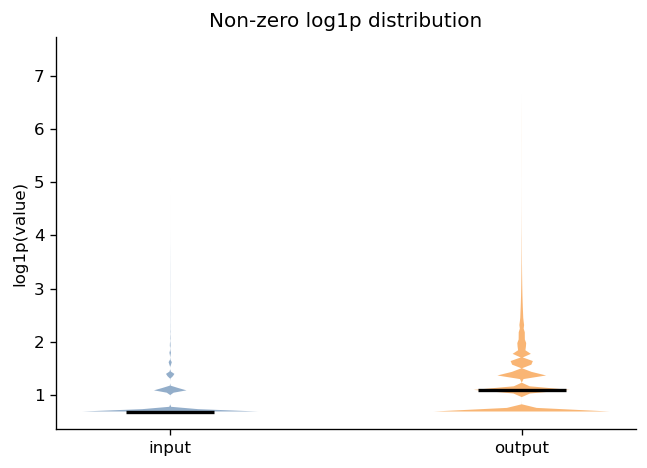

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 4))
parts = ax.violinplot(
    [np.log1p(input_nonzero), np.log1p(output_nonzero)],
    showmeans=False,
    showmedians=True,
    showextrema=False,
)
for body, color in zip(parts['bodies'], [colors['input'], colors['output']]):
    body.set_facecolor(color)
    body.set_edgecolor('none')
    body.set_alpha(0.6)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)
ax.set_xticks([1, 2])
ax.set_xticklabels(['input', 'output'])
ax.set_title('Non-zero log1p distribution')
ax.set_ylabel('log1p(value)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()

In [11]:
# Optional: inspect a small top-left block of both matrices.
input_preview = pd.read_csv(input_tsv, sep='\t', index_col=0, nrows=5)
output_preview = pd.read_csv(output_tsv, sep='\t', index_col=0, nrows=5)

print('Input preview:')
display(input_preview.iloc[:, :5])

print('Output preview:')
display(output_preview.iloc[:, :5])

Input preview:


,14mWT-3,14mWT-58,14mWT-59,14mWT-86,14mWT-88
1700019D03Rik,0,0,0,0,0
A2m,0,0,0,0,0
Aamp,0,0,0,0,0
Abat,0,0,0,0,1
Abca1,0,0,0,0,0


Output preview:


,14mWT-3,14mWT-58,14mWT-59,14mWT-86,14mWT-88
1700019D03Rik,0.0,0.0,0.0,0.0,0.0
A2m,0.0,0.0,0.0,1.0,2.0
Aamp,0.0,1.0,1.0,1.0,0.0
Abat,0.0,0.0,0.0,3.0,1.0
Abca1,1.0,1.0,1.0,2.0,2.0
